<a href="https://colab.research.google.com/github/alexkjohnson/fastai2019/blob/main/03_minibatch_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/alexkjohnson/fastai2019.git

Cloning into 'fastai2019'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 310.79 KiB | 1.77 MiB/s, done.


In [ ]:
import os
os.chdir('fastai2019')

In [ ]:
!pwd

/content/fastai2019/fastai2019


---

In [ ]:
import os
import urllib.request

from pathlib import Path
from IPython.core.debugger import set_trace
# from fastai import datasets
import pickle, gzip, math, torch, matplotlib as mpl
import matplotlib.pyplot as plt
from torch import tensor

In [ ]:
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/fastai2019/fastai2019/mnist.pkl.gz


In [ ]:
with gzip.open(path, 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

In [ ]:
def get_data(path):
    # path = datasets.download_data(MNIST_URL, ext='.gz')
    with gzip.open(path, 'rb') as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')
    return map(tensor, (x_train,y_train,x_valid,y_valid))

def normalize(x, m, s): return (x-m)/s

In [ ]:
def test(a,b,cmp,cname=None):
    if cname is None: cname=cmp.__name__
    assert cmp(a,b),f"{cname}:\n{a}\n{b}"

def test_eq(a,b): test(a,b,operator.eq,'==')

In [ ]:
def near(a,b): return torch.allclose(a, b, rtol=1e-3, atol=1e-5)
def test_near(a,b): test(a,b,near)

---

In [ ]:
import torch.nn.functional as F
from torch import nn

## Initial setup
### Data

In [ ]:
mpl.rcParams['image.cmap'] = 'gray'

In [ ]:
x_train,y_train,x_valid,y_valid = get_data(path)

In [ ]:
n,m = x_train.shape
c = y_train.max()+1
nh = 50

In [ ]:
class Model(nn.Module):
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        self.layers = [nn.Linear(n_in,nh), nn.ReLU(), nn.Linear(nh,n_out)]

    def __call__(self, x):
        for l in self.layers: x = l(x)
        return x

In [ ]:
model = Model(m, nh, 10)

In [ ]:
pred = model(x_train)

can now improve our loss function from MSE  
now that we're using PyTorch's autograd we can use many more things because we don't have to write our own gradients  
remember: in the case of multi-class categorical cross entropy you first do softmax, followed by Negative Log-Likelihood (NLL)

### Cross entropy loss
First, we will need to compute the softmax of our activations. This is defined by:

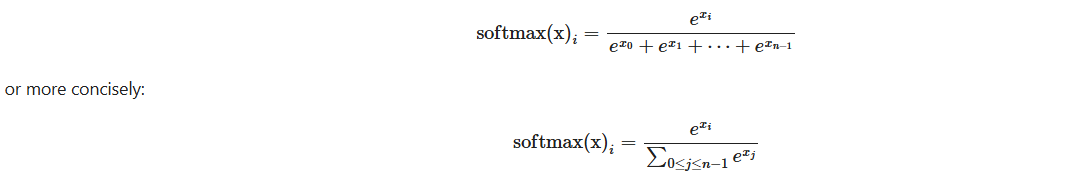

In practice, we will need the log of the softmax when we calculate the loss.

In [ ]:
def log_softmax(x): return (x.exp()/(x.exp().sum(-1,keepdim=True))).log()

we do a `.log()` on the whole thing because in PyTorch NLL expects a log softmax (will see why shortly)

In [ ]:
sm_pred = log_softmax(pred)

The cross entropy loss for some target x and some prediction p(x) is given by:  

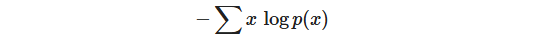



But since our x's are 1-hot encoded, this can be rewritten as -log(pi) where i is the index of the desired target

This can be done using numpy-style integer array indexing. Note that PyTorch supports all the tricks in the advanced indexing methods discussed in that link.

In [ ]:
y_train[:3]

tensor([5, 0, 4])

In [ ]:
sm_pred[0][5]

tensor(-2.3530, grad_fn=<SelectBackward0>)

indexes are a list of all the row and col indexes you want respectively

In [ ]:
sm_pred[[0,1,2], [5,0,4]]

tensor([-2.3530, -2.2873, -2.0683], grad_fn=<IndexBackward0>)

In [ ]:
y_train.shape[0]

50000

In [ ]:
def nll(input, target): return -input[range(target.shape[0]), target].mean()

rows: 0->49999 and which cols we want for each of those rows / whatever our target value is (the actual value)

we can now calculate the nll by taking the sm_pred (calculated above), compared to our actual (y_train)

In [ ]:
loss = nll(sm_pred, y_train)

In [ ]:
loss

tensor(2.2858, grad_fn=<NegBackward0>)

Note that the formula

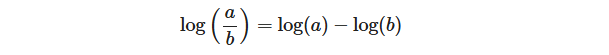

gives a simplification when we compute the log softmax, which was previously defined as `(x.exp()/(x.exp().sum(-1,keepdim=True))).log()`

In [ ]:
def log_softmax(x): return x - x.exp().sum(-1,keepdim=True).log()

In [ ]:
test_near(nll(log_softmax(pred), y_train), loss)

Then, there is a way to compute the log of the sum of exponentials in a more stable way, called the LogSumExp trick. The idea is to use the following formula:  

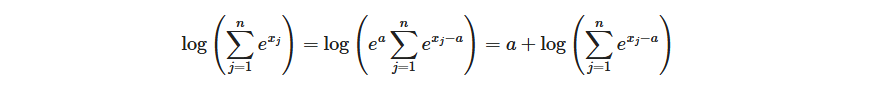

where a is the maximum of the xj.

the reason you need this trick: e^x (`x.exp()`) can result in ridiculously big numbers
- very big numbers in floating point on a computer are really inaccurate - basically the further you get away from 0, the less fine-grained they are. gets to the point where 2 number eg: 1000 apart the computer thinks they're the same number
- so you don't want big numbers, particularly when you're calculating gradients
- so take note anywhere you see `x.exp()` as we don't want `x` to be big
- the mathematical substitution above allows us to subtract a number from your `x`'s and add them back at the front, and you get the same answer
- what you can do: find & subtract the max x from all of your x's, then add it back afterwards outside the exp and get exactly the same answer
- this is a really helpful numerical stability trick

In [ ]:
def logsumexp(x):
    m = x.max(-1)[0]
    return m + (x-m[:,None]).exp().sum(-1).log()

This way, we will avoid an overflow when taking the exponential of a big activation.  
In PyTorch, this is already implemented for us.

In [ ]:
test_near(logsumexp(pred), pred.logsumexp(-1))

So we can use it for our `log_softmax` function.

In [ ]:
def log_softmax(x): return x - x.logsumexp(-1,keepdim=True)

In [ ]:
test_near(nll(log_softmax(pred), y_train), loss)

Then use PyTorch's implementation.

In [ ]:
test_near(F.nll_loss(F.log_softmax(pred, -1), y_train), loss)

In PyTorch, `F.log_softmax` and `F.nll_loss` are combined in one optimized function, `F.cross_entropy`.

In [ ]:
test_near(F.cross_entropy(pred, y_train), loss)

have now recreated PyTorch's `F.cross_entropy`

now that we have a loss fn we can use it to train

## Basic training loop
Basically the training loop repeats over the following steps:
- get the output of the model on a batch of inputs
- compare the output to the labels we have and compute a loss
- calculate the gradients of the loss with respect to every parameter of the model
- update said parameters with those gradients to make them a little bit better
- zero the gradients

In [ ]:
loss_func = F.cross_entropy

can now use this loss fn to train.

might aswell also define a metric because it's nice to see accuracy to be able to see how we're going (because it's much more interpretable)

In [ ]:
def accuracy(out, yb): return (torch.argmax(out, dim=1)==yb).float().mean()

remember:
- `argmax` to find which of the numbers in our softmax is the highest, and the index of that is our prediction
- then check whether that's equal to the actual (`yb`)
- then take the `mean` of `float`'s (because you can't take the mean of int's in PyTorch)

In [ ]:
bs=64                  # batch size

xb = x_train[0:bs]     # a mini-batch from x
preds = model(xb)      # predictions
preds[0], preds.shape

(tensor([-0.1439, -0.0512,  0.0660, -0.1033,  0.1496, -0.0402,  0.0209,  0.0036,
          0.0855,  0.0775], grad_fn=<SelectBackward0>),
 torch.Size([64, 10]))

In [ ]:
yb = y_train[0:bs]
loss_func(preds, yb)

tensor(2.2886, grad_fn=<NllLossBackward0>)

In [ ]:
accuracy(preds, yb)

tensor(0.0938)

as we can see we have an accuracy of around 10% as we haven't yet trained our model  
we've got a model that's giving basically random answers. so let's train it:

In [ ]:
lr = 0.5   # learning rate
epochs = 1 # how many epochs to train for

https://github.com/fastai/course-v3/blob/9da9cc55f8b93868eed962fdcbe3365f838e0ca1/nbs/dl1/lesson2-sgd.ipynb

    def update():
        y_hat = x@a
        loss = mse(y, y_hat)
        if t % 10 == 0: print(loss)
        loss.backward()
        with torch.no_grad():
            a.sub_(lr * a.grad)
            a.grad.zero_()


remember from part 1 our training loops looks as shown above
- calculate the preds: `y_hat = x@a`
- calculate the loss: `loss = mse(y, y_hat)`
- do a backward pass: `loss.backward()`
- update; subtract lr * grads: `a.sub_(lr * a.grad)`
- zero the gradients: `a.grad.zero_()`


In [ ]:
for epoch in range(epochs):
    for i in range((n-1)//bs + 1):
#         set_trace()
        start_i = i*bs
        end_i = start_i+bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        loss = loss_func(model(xb), yb)

        loss.backward()
        with torch.no_grad():
            for l in model.layers:
                if hasattr(l, 'weight'):
                    l.weight -= l.weight.grad * lr
                    l.bias   -= l.bias.grad   * lr
                    l.weight.grad.zero_()
                    l.bias  .grad.zero_()

remember: the **update** has to be done with `no_grad` because this is not part of the gradient calculation - this is the result of it.

now we can't just go `a.sub_(lr * a.grad)` - we have to do that for every one of our parameters.  
Our model has 3 layers: `self.layers = [nn.Linear(n_in,nh), nn.ReLU(), nn.Linear(nh,n_out)]`
- `ReLU` has no parameters in it
- each `Linear` layer has `weight` & `bias`

above we just go through all of our layers and check whether that layer has an attribute called `weight`.  
If it does we update the weight's / bias', then `zero_` them when we're done



In [ ]:
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.1200, grad_fn=<NllLossBackward0>), tensor(0.9375))

can see that loss has gone down & accuracy up.  
note: the accuracy is for only a single mini-batch & it's a mini-batch from the training set so it doesn't mean too much, but obviously our model is learning something :)

**we now have a basic training loop**

Let's make this simpler - becuase it's currently too much code / hard to work with

firstly; let's get rid of:

    with torch.no_grad():
        for l in model.layers:
            if hasattr(l, 'weight'):
                l.weight -= l.weight.grad * lr
                l.bias   -= l.bias.grad   * lr
                l.weight.grad.zero_()
                l.bias  .grad.zero_()

and replace it with:

    with torch.no_grad():
        for p in model.parameters(): p -= p.grad * lr
            model.zero_grad()

the difference:
- rather than manually going through `weight` & `bias` for each layer, we're going to loop through `model.parameters` - we're not even going to loop through the layers but loop directly through `model.parameters`
- for each parameter: `p -= p.grad * lr`

-> We need to be able to get all of the parameters of our model
- this allows us to greatly simplify the training loop & also make it much more flexible
- to do that, we can create something like: `DummyModule`


## Using parameters and optim
### Parameters
Use `nn.Module.__setattr__` and move relu to functional:

In [ ]:
class Model(nn.Module):
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        self.l1 = nn.Linear(n_in,nh)
        self.l2 = nn.Linear(nh,n_out)

    def __call__(self, x): return self.l2(F.relu(self.l1(x)))

In [ ]:
model = Model(m, nh, 10)

In [ ]:
for name,l in model.named_children(): print(f"{name}: {l}")

l1: Linear(in_features=784, out_features=50, bias=True)
l2: Linear(in_features=50, out_features=10, bias=True)


PyTorch also has a `__repr__` allowing you to print out the model:

In [ ]:
model

Model(
  (l1): Linear(in_features=784, out_features=50, bias=True)
  (l2): Linear(in_features=50, out_features=10, bias=True)
)

In [ ]:
model.l1

Linear(in_features=784, out_features=50, bias=True)

In [ ]:
def fit():
    for epoch in range(epochs):
        for i in range((n-1)//bs + 1):
            start_i = i*bs
            end_i = start_i+bs
            xb = x_train[start_i:end_i]
            yb = y_train[start_i:end_i]
            loss = loss_func(model(xb), yb)

            loss.backward()
            with torch.no_grad():
                for p in model.parameters(): p -= p.grad * lr
                model.zero_grad()

In [ ]:
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.1158, grad_fn=<NllLossBackward0>), tensor(0.9375))

Behind the scenes, PyTorch overrides the `__setattr__` function in `nn.Module` so that the submodules you define are properly registered as parameters of the model.

In [ ]:
class DummyModule():
    def __init__(self, n_in, nh, n_out):
        self._modules = {}
        self.l1 = nn.Linear(n_in,nh)
        self.l2 = nn.Linear(nh,n_out)

    def __setattr__(self,k,v):
        if not k.startswith("_"): self._modules[k] = v
        super().__setattr__(k,v)

    def __repr__(self): return f'{self._modules}'

    def parameters(self):
        for l in self._modules.values():
            for p in l.parameters(): yield p

Every time an attribute is set, such as `l1` or `l2` (in this case to `Linear`), want to update a list called `_modules` with a list of all of the modules we have
- aka; after we create this `DummyModule`, want to be able to print out (`__repr__`) a list of those modules and see the modules that're there
- can then define a `parameters` method that's go through everything in `_modules` list, then go through all of their `parameters`

`__setattr__` method: everytime that you assign to anything inside `self` it will call this method if available
- `if not k.startswith("_"): self._modules[k] = v`: checks whether the key (attribute name) doesn't start with `_`
  - if not: put that value inside `_modules` dictionary and call it `k`
    - if it does it might be something such as `_modules` -> recursive loop
    - python also has all kinds of internal stuff that starts with `_`
- `super().__setattr__(k,v)`: does whatever the superclass does when it sets attributes - in this case the superclass is 'object' - if you don't say what it is then it's just the Python highest level object

now we have everything we need to refactor
- PyTorch's `nn.Module` also does this -> rather than implementing that `__setattr__` functionality ourselves we can just inherit from `nn.Module`
- this is why you have to call `super().__init__()` first; because it has to set up it's equivalent of this `_modules` dictionary

In [ ]:
mdl = DummyModule(m,nh,10)
mdl

{'l1': Linear(in_features=784, out_features=50, bias=True), 'l2': Linear(in_features=50, out_features=10, bias=True)}

In [ ]:
[o.shape for o in mdl.parameters()]

[torch.Size([50, 784]),
 torch.Size([50]),
 torch.Size([10, 50]),
 torch.Size([10])]

## Registering modules
We can use the original `layers` approach, but we have to register the modules.

can further refactor: to get rid of the need to write every layer seperately / maybe having it as a list again

the only thing's that PyTorch is going to make available as parameters are things it knows are proper `nn.Module`'s

In [ ]:
layers = [nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10)]

In [ ]:
class Model(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = layers
        for i,l in enumerate(self.layers): self.add_module(f'layer_{i}', l)

    def __call__(self, x):
        for l in self.layers: x = l(x)
        return x

In [ ]:
model = Model(layers)

In [ ]:
model

Model(
  (layer_0): Linear(in_features=784, out_features=50, bias=True)
  (layer_1): ReLU()
  (layer_2): Linear(in_features=50, out_features=10, bias=True)
)

that's one solution - kind of clunky / would be nicer for PyTorch to do it for you.

## nn.ModuleList
`nn.ModuleList` does this for us.

`nn.ModuleList` basically calls: `for i,l in enumerate(self.layers): self.add_module(f'layer_{i}', l)`

In [ ]:
class SequentialModel(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def __call__(self, x):
        for l in self.layers: x = l(x)
        return x

In [ ]:
model = SequentialModel(layers)

In [ ]:
model

SequentialModel(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)

In [ ]:
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.0579, grad_fn=<NllLossBackward0>), tensor(1.))

even this is a little on the clunky side / don't have to write it ourselves as PyTorch has that code already:

## nn.Sequential
`nn.Sequential` is a convenient class which does the same as the above:

In [ ]:
model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))

In [ ]:
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.0586, grad_fn=<NllLossBackward0>), tensor(1.))

In [ ]:
# nn.Sequential??

In [ ]:
model

Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=10, bias=True)
)

## optim
Let's replace our previous manually coded optimization step:

    with torch.no_grad():
        for p in model.parameters(): p -= p.grad * lr
        model.zero_grad()

and instead use just:

    opt.step()
    opt.zero_grad()

In [ ]:
class Optimizer():
    def __init__(self, params, lr=0.5):
      self.params,self.lr = list(params),lr

    def step(self):
        with torch.no_grad():
            for p in self.params: p -= p.grad * self.lr

    def zero_grad(self):
        for p in self.params: p.grad.data.zero_()

`opt.step` has to do: `for p in model.parameters(): p -= p.grad * lr`

In [ ]:
model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))

In [ ]:
opt = Optimizer(model.parameters())

In [ ]:
for epoch in range(epochs):
    for i in range((n-1)//bs + 1):
        start_i = i*bs
        end_i = start_i+bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

In [ ]:
loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
loss,acc

(tensor(0.1029, grad_fn=<NllLossBackward0>), tensor(0.9375))

PyTorch already provides this exact functionality in `optim.SGD` (it also handles stuff like momentum, which we'll look at later - except we'll be doing it in a more flexible way!)

In [ ]:
from torch import optim

In [ ]:
# optim.SGD.step??

now; if we're going to use all of the parameters of the model can create a `get_model` fn:
- creates our model
- returns the model, aswell as `SGD` optimizer with all of the parameters

In [ ]:
def get_model():
    model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))
    return model, optim.SGD(model.parameters(), lr=lr)

In [ ]:
model,opt = get_model()
loss_func(model(xb), yb)

tensor(2.3272, grad_fn=<NllLossBackward0>)

In [ ]:
for epoch in range(epochs):
    for i in range((n-1)//bs + 1):
        start_i = i*bs
        end_i = start_i+bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

In [ ]:
loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
loss,acc

(tensor(0.1297, grad_fn=<NllLossBackward0>), tensor(0.9375))

Randomized tests can be very useful.

In [ ]:
assert acc>0.7

## Dataset and DataLoader
### Dataset
It's clunky to iterate through minibatches of x and y values separately:

    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]
Instead, let's do these two steps together, by introducing a `Dataset` class:

    xb,yb = train_ds[i*bs : i*bs+bs]

- an object that we can pass in the indexes we want and get back both x & y

In [ ]:
class Dataset():
    def __init__(self, x, y): self.x,self.y = x,y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i],self.y[i]

In [ ]:
train_ds,valid_ds = Dataset(x_train, y_train),Dataset(x_valid, y_valid)
assert len(train_ds)==len(x_train)
assert len(valid_ds)==len(x_valid)

In [ ]:
xb,yb = train_ds[0:5]
assert xb.shape==(5,28*28)
assert yb.shape==(5,)
xb,yb

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([5, 0, 4, 1, 9]))

In [ ]:
model,opt = get_model()

In [ ]:
for epoch in range(epochs):
    for i in range((n-1)//bs + 1):
        xb,yb = train_ds[i*bs : i*bs+bs]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

In [ ]:
loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
assert acc>0.7
loss,acc

(tensor(0.0077, grad_fn=<NllLossBackward0>), tensor(1.))

## DataLoader
Previously, our loop iterated over batches (xb, yb) like this:
```
for i in range((n-1)//bs + 1):
    xb,yb = train_ds[i*bs : i*bs+bs]
    ...
```
Let's make our loop much cleaner, using a data loader:
```
for xb,yb in train_dl:
    ...
```

to do that, we need a class that takes:
- a dataset
- a batch size

`for xb,yb in train_dl:` behind the scenes in Python calls `__iter__`

- go through the dataset jumping up `self.bs` at a time (eg: 0,64,128,etc up to 50000)
- each time through we `yield` our dataset starting at index `i`, ending at `i+self.bs`
  - `yield` (coroutine) allows us to have a fn that doesn't just return one thing once but can can ask for it to return lots of things over
- `__iter__` basically returns something you can call `next` on many times, and each time you call `next` it will return the next thing that is `yield`ed

In [ ]:
class DataLoader():
    def __init__(self, ds, bs): self.ds,self.bs = ds,bs
    def __iter__(self):
        for i in range(0, len(self.ds), self.bs): yield self.ds[i:i+self.bs]

In [ ]:
train_dl = DataLoader(train_ds, bs)
valid_dl = DataLoader(valid_ds, bs)

In [ ]:
xb,yb = next(iter(valid_dl))
assert xb.shape==(bs,28*28)
assert yb.shape==(bs,)

- `iter(valid_dl)` is the thing that generates our coroutine
- `next()` grabs the next thing yielded out of that coroutine
  - that returns one thing from our dataset - and our dataset return 2 thing as specified: `xb,yb`

tensor(3)

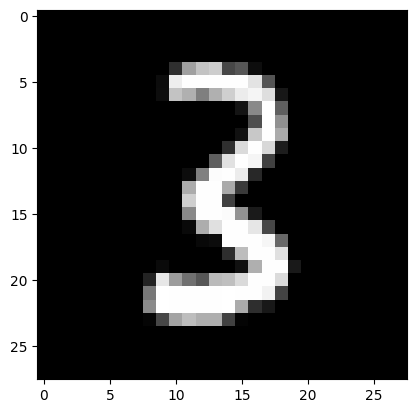

In [ ]:
plt.imshow(xb[0].view(28,28))
yb[0]

In [ ]:
model,opt = get_model()

In [ ]:
def fit():
    for epoch in range(epochs):
        for xb,yb in train_dl:
            pred = model(xb)
            loss = loss_func(pred, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()

this is about as neat as we can get

at this point this dataset and dataloader are the same abstractions that PyTorch uses

In [150]:
fit()

In [151]:
loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
assert acc>0.7
loss,acc

(tensor(0.1266, grad_fn=<NllLossBackward0>), tensor(0.9688))

problem: we're always looping through the training set in order
- because we lose the randomness of shuffling it each time
- particularly if our training set was already ordered by a dependent variable, then every batch is going to be exactly the same dependent variable

therefore, we want to shuffle it:

## Random sampling
We want our training set to be in a random order, and that order should differ each iteration. But the validation set shouldn't be randomized.

In [152]:
class Sampler():
    def __init__(self, ds, bs, shuffle=False):
        self.n,self.bs,self.shuffle = len(ds),bs,shuffle

    def __iter__(self):
        self.idxs = torch.randperm(self.n) if self.shuffle else torch.arange(self.n)
        for i in range(0, self.n, self.bs): yield self.idxs[i:i+self.bs]

remember: `__iter__` allows us to call `next()` multiple times
- if we are shuffling `self.shuffle`, then grab a random permutation of the n to n-1 (`torch.randperm(self.n)`), otherwise grab all integers in order to n-1: `torch.arange(self.n)`
- then, as before go through the `range` and `yield` the indexes

In [153]:
small_ds = Dataset(*train_ds[:10])

In [154]:
s = Sampler(small_ds,3,False)
[o for o in s]

[tensor([0, 1, 2]), tensor([3, 4, 5]), tensor([6, 7, 8]), tensor([9])]

In [156]:
s = Sampler(small_ds,3,True)
[o for o in s]

[tensor([8, 4, 1]), tensor([7, 3, 2]), tensor([9, 6, 5]), tensor([0])]

In [158]:
def collate(b):
    xs,ys = zip(*b)
    return torch.stack(xs),torch.stack(ys)

class DataLoader():
    def __init__(self, ds, sampler, collate_fn=collate):
        self.ds,self.sampler,self.collate_fn = ds,sampler,collate_fn

    def __iter__(self):
        for s in self.sampler: yield self.collate_fn([self.ds[i] for i in s])

can now pass our `DataLoader` a `sampler`
- then loop (`__iter__`) through `for s in self.sampler`
  - because we're using `yield` these are only going to be calculated when asked, they're not all calculated up front -> can use these on really big datasets no problem
- `collate` grabs the x's & y's and stacks them up / collates them all together into a single pair of tensors
  - `torch.stack` grabs a bunch of tensors and "glues" them together on a new axis
- can pass in a different collate fn if you want to do some things such as padding, etc, so can pass in a different collate fn

In [159]:
train_samp = Sampler(train_ds, bs, shuffle=True)
valid_samp = Sampler(valid_ds, bs, shuffle=False)

In [160]:
train_dl = DataLoader(train_ds, sampler=train_samp, collate_fn=collate)
valid_dl = DataLoader(valid_ds, sampler=valid_samp, collate_fn=collate)

tensor(3)

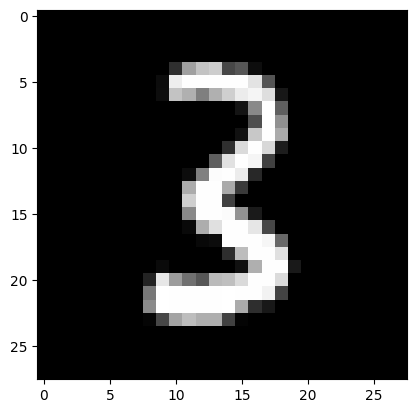

In [161]:
xb,yb = next(iter(valid_dl))
plt.imshow(xb[0].view(28,28))
yb[0]

tensor(1)

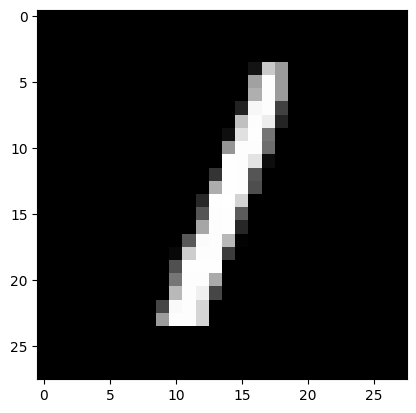

In [162]:
xb,yb = next(iter(train_dl))
plt.imshow(xb[0].view(28,28))
yb[0]

tensor(8)

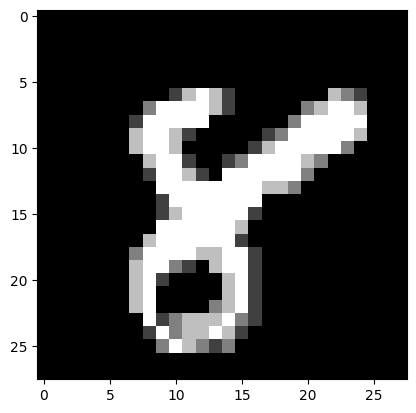

In [163]:
xb,yb = next(iter(train_dl))
plt.imshow(xb[0].view(28,28))
yb[0]

can see that the dataset is being shuffled

In [164]:
model,opt = get_model()
fit()

loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
assert acc>0.7
loss,acc

(tensor(0.1253, grad_fn=<NllLossBackward0>), tensor(0.9688))

the PyTorch DataLoader does exactly that - let's import it:

## PyTorch DataLoader


In [165]:
from torch.utils.data import DataLoader, SequentialSampler, RandomSampler

can see it takes exactly the same arguments & can even pass in the collate fn defined above

it doesn't have a single sampler that you pass `shuffle=True` or `False` to, but has 2 samplers:
- `RandomSampler`
- `SequentialSampler`
  - slightly different to the api we defined above but does exactly the same thing

In [166]:
train_dl = DataLoader(train_ds, bs, sampler=RandomSampler(train_ds), collate_fn=collate)
valid_dl = DataLoader(valid_ds, bs, sampler=SequentialSampler(valid_ds), collate_fn=collate)

In [167]:
model,opt = get_model()
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.2069, grad_fn=<NllLossBackward0>), tensor(0.9375))

PyTorch's defaults work fine for most things however:

most of the time you don't need the flexibility of writing your own sampler & collation fn, so you can just pass in `shuffle` and it will use a default sample & collation fn that work the way we've just shown.

In [168]:
train_dl = DataLoader(train_ds, bs, shuffle=True, drop_last=True)
valid_dl = DataLoader(valid_ds, bs, shuffle=False)

In [169]:
model,opt = get_model()
fit()

loss,acc = loss_func(model(xb), yb), accuracy(model(xb), yb)
assert acc>0.7
loss,acc

(tensor(0.0986, grad_fn=<NllLossBackward0>), tensor(0.9688))

Note that PyTorch's `DataLoader`, if you pass `num_workers`, will use multiple threads to call your `Dataset`.
- will fire off that many processors & each one will seperately grab stuff out of your `Dataset`, then it will collate them together afterwards
- so if your `Dataset`'s doing things like opening big jpeg files, doing big image transformations, that's a really good idea

## Validation
You **always** should also have a validation set, in order to identify if you are overfitting.

We will calculate and print the validation loss at the end of each epoch.

(Note that we always call `model.train()` before training, and `model.eval()` before inference, because these are used by layers such as `nn.BatchNorm2d` and `nn.Dropout` to ensure appropriate behaviour for these different phases.)

here's the same loops as before but with `torch.no_grad()` going through the validation set
- for this we grab the preds & loss as before but don't call backward & don't step the optimizer
- instead we just keep track of the loss & also the accuracy

the only other differce is that we've added `model.train()` and `model.eval()`
- all this does is sets an internal attribute called `.training` to `True` or `False`

In [174]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    for epoch in range(epochs):
        # Handle batchnorm / dropout
        model.train()
        # print(model.training)
        for xb,yb in train_dl:
            loss = loss_func(model(xb), yb)
            loss.backward()
            opt.step()
            opt.zero_grad()

        model.eval()
        # print(model.training)
        with torch.no_grad():
            tot_loss,tot_acc = 0.,0.
            for xb,yb in valid_dl:
                pred = model(xb)
                tot_loss += loss_func(pred, yb)
                tot_acc  += accuracy (pred,yb)
        nv = len(valid_dl)
        print(epoch, tot_loss/nv, tot_acc/nv)
    return tot_loss/nv, tot_acc/nv

Question: Are these validation results correct if batch size varies?
- No. It does not work correctly when your batch size varies.
- eg: if you had 1 mini-batch of size 1000 & 1 mini-batch of size 1, you can't just do: `epoch, tot_loss/nv, tot_acc/nv`
- you need a weighted average weighted by the size of the mini-batch
  - this incorrect way is how nearly every library does it, fastai does it the proper way - next time we do this we'll implement it the proper way

`get_dls` returns dataloaders for the training and validation sets:

---



In [172]:
def get_dls(train_ds, valid_ds, bs, **kwargs):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True, **kwargs),
            DataLoader(valid_ds, batch_size=bs*2, **kwargs))

we don't need to do the backward pass for the validation dataset, so we don't need to store the gradients -> means we have twice as much room, so we can double the batch size: `batch_size=bs*2`

Now, our whole process of obtaining the data loaders and fitting the model can be run in 3 lines of code:

In [176]:
train_dl,valid_dl = get_dls(train_ds, valid_ds, bs)
model,opt = get_model()
loss,acc = fit(5, model, loss_func, opt, train_dl, valid_dl)

0 tensor(0.1383) tensor(0.9585)
1 tensor(0.1357) tensor(0.9595)
2 tensor(0.1458) tensor(0.9553)
3 tensor(0.1119) tensor(0.9675)
4 tensor(0.0965) tensor(0.9722)


`model.training` is set to either True or False because some layers have different behavior depending on whether it's training or validation
- eg: batchnorm only updates its running statistics if it's training, dropout - they're the 2 main ones

In [177]:
assert acc>0.9